## Next GEMS data extraction

In [76]:
import xarray as xr
import numpy as np
import matplotlib.pylab as plt
import matplotlib.cm as cm
import cmocean.cm as cmo
from scipy.interpolate import CloughTocher2DInterpolator, LinearNDInterpolator, NearestNDInterpolator
import gribscan
import intake

In [117]:
def attach_coords(ds):
    model_lon = ds.lon.values
    model_lat = ds.lat.values
    return ds.assign_coords(
        lat = (("value",), model_lat, {"units": "degree_north"}),
        lon = (("value",), model_lon, {"units": "degree_east"}),
    )


def attach_depth_coords(ds):
    nz1  = [2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5,
    62.5, 67.5, 72.5, 77.5, 82.5, 87.5, 92.5, 97.5, 105, 115, 125, 135, 145,
    155, 165, 175, 185, 195, 210, 230, 250, 270, 290, 320, 360, 400, 440,
    480, 520, 560, 600, 640, 710, 810, 950, 1110, 1255, 1415, 1600, 1810,
    2035, 2275, 2525, 2775, 3025, 3275, 3525, 3775, 4025, 4275, 4525, 4775,
    5025, 5275, 5525, 5825, 6175, 6175]
    nz = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85,
    90, 95, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 220, 240,
    260, 280, 300, 340, 380, 420, 460, 500, 540, 580, 620, 660, 760, 860,
    1040, 1180, 1330, 1500, 1700, 1920, 2150, 2400, 2650, 2900, 3150, 3400,
    3650, 3900, 4150, 4400, 4650, 4900, 5150, 5400, 5650, 6000, 6350]
    return ds.assign_coords(
        nz1 = (("level",), nz1, {"units": "m"}),
        nz = (("level",), nz, {"units": "m"}),
    )

In [85]:
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
print(list(cat.FESOM))

['IFS_4.4-FESOM_5-cycle3', 'IFS_28-FESOM_25-cycle3', 'IFS_9-FESOM_5-cycle3', 'FESOM_13_tropo_age_interpolated']


In [115]:
print(list(cat.IFS['IFS_9-FESOM_5-production'])) 

['2D_hourly_healpix512', '2D_hourly_healpix512_2020s', '2D_hourly_healpix512_2030s', '2D_hourly_healpix512_2040s', '2D_hourly_healpix512_sst_ci_winds_2035', '2D_hourly_healpix512_sst_ci_winds_2040s', '3D_hourly_healpix512', '3D_hourly_healpix512_2020', '3D_hourly_healpix512_2025', '3D_hourly_healpix512_2030', '3D_hourly_healpix512_2035', '3D_hourly_healpix512_2040', '3D_hourly_healpix512_2045', '3D_hourly_healpix512_snow', '2D_hourly_healpix512_winds100m', '2D_hourly_healpix512_windspeed100m', '2D_daily_healpix512_ocean', '3D_daily_healpix512_ocean', '2D_monthly_healpix512', '2D_monthly_healpix512_sst_ci_winds', '2D_monthly_healpix512_winds100m', '2D_monthly_healpix512_windspeed100m', '3D_monthly_healpix512', '3D_monthly_healpix512_snow', '2D_hourly_healpix128', '2D_hourly_healpix128_sst_ci_winds', '3D_hourly_healpix128', '3D_hourly_healpix128_2020', '3D_hourly_healpix128_2025', '3D_hourly_healpix128_2030', '3D_hourly_healpix128_2035', '3D_hourly_healpix128_2040', '3D_hourly_healpix128

In [118]:
data = cat.IFS['IFS_9-FESOM_5-production']['3D_daily_healpix512_ocean'].to_dask().pipe(attach_depth_coords)
data

/home/b/b383184/.local/lib/python3.12/site-packages/zarr/core/metadata/v2.py:191: UserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, UserWarning, stacklevel=1)
/home/b/b383184/.local/lib/python3.12/site-packages/zarr/core/metadata/v2.py:191: UserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, UserWarning, stacklevel=1)
/home/b/b383184/.local/lib/python3.12/site-packages/zarr/core/metadata/v2.py:191: UserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a

<xarray.Dataset> Size: 95TB
Dimensions:     (time: 10816, level: 70, value: 3145728)
Coordinates:
  * time        (time) datetime64[ns] 87kB 2020-01-21 2020-01-22 ... 2050-01-01
  * level       (level) int64 560B 1 2 3 4 5 6 7 8 9 ... 63 64 65 66 67 68 69 70
    lon         (value) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
    lat         (value) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
    nz1         (level) float64 560B 2.5 7.5 12.5 ... 6.175e+03 6.175e+03
    nz          (level) int64 560B 0 5 10 15 20 25 ... 5150 5400 5650 6000 6350
Dimensions without coordinates: value
Data variables:
    avg_uoe     (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_wo      (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_von     (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_thetao  (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_so      (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
Attributes:
    edition:            2
    centre:             ecmf
    centreDescription:  European Centre for Medium-Range Weather Forecasts
    subCentre:          1003
    history:            🪄🧙‍♂️🔮 magic dataset assembly provided by gribscan.IF...

In [137]:
ds = data.sel(time=slice('01-06-2022','01-07-2025'))
ds

<xarray.Dataset> Size: 10TB
Dimensions:     (time: 1098, level: 70, value: 3145728)
Coordinates:
  * time        (time) datetime64[ns] 9kB 2022-01-06 2022-01-07 ... 2025-01-07
  * level       (level) int64 560B 1 2 3 4 5 6 7 8 9 ... 63 64 65 66 67 68 69 70
    lon         (value) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
    lat         (value) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
    nz1         (level) float64 560B 2.5 7.5 12.5 ... 6.175e+03 6.175e+03
    nz          (level) int64 560B 0 5 10 15 20 25 ... 5150 5400 5650 6000 6350
Dimensions without coordinates: value
Data variables:
    avg_uoe     (time, level, value) float64 2TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_wo      (time, level, value) float64 2TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_von     (time, level, value) float64 2TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_thetao  (time, level, value) float64 2TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_so      (time, level, value) float64 2TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
Attributes:
    edition:            2
    centre:             ecmf
    centreDescription:  European Centre for Medium-Range Weather Forecasts
    subCentre:          1003
    history:            🪄🧙‍♂️🔮 magic dataset assembly provided by gribscan.IF...

In [132]:
newshape=(len(np.unique(data.isel(time=0,level=0).lat)),len(np.unique(data.isel(time=0,level=0).lon)))
print(newshape)

data.avg_thetao.isel(time=0,level=0).values.shape

(2047, 445327)


(3145728,)

TypeError: Invalid shape (3145728,) for image data

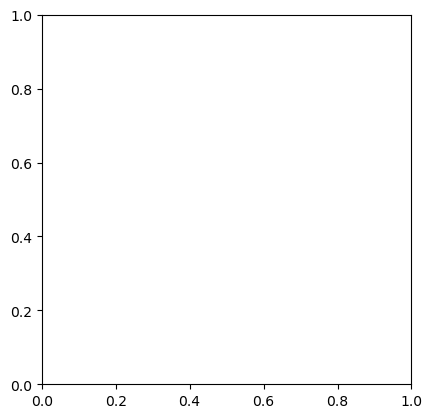

In [135]:
# here we reshape with newshape 
# sample = np.reshape(data.avg_thetao.isel(time=0,level=0).values, newshape=(len(np.unique(data.lat)),len(np.unique(data.lon))))

plt.imshow(data.avg_thetao.isel(time=0,level=0).values)
# data.cswc.attrs

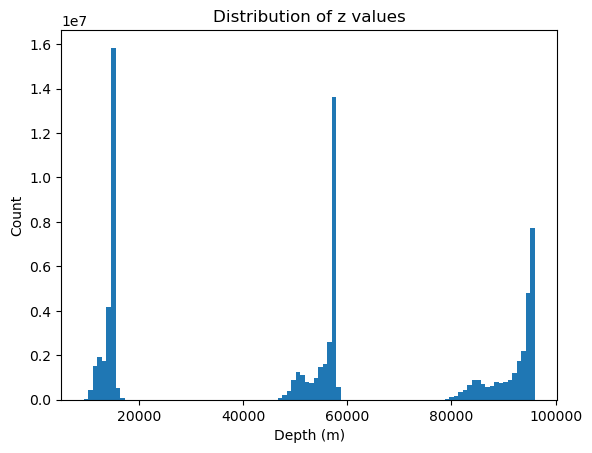

In [52]:
# For one time step and one level
zz = data.isel(time=0).z

import matplotlib.pyplot as plt
z_flat = zz.values.flatten()
plt.hist(z_flat[~np.isnan(z_flat)], bins=100)
plt.xlabel("Depth (m)")
plt.ylabel("Count")
plt.title("Distribution of z values")
plt.show()
# compute().data[()]

In [53]:
data.z.attrs

{'paramId': 129,
 'dataType': 'fc',
 'numberOfPoints': 26306560,
 'typeOfLevel': 'isobaricInhPa',
 'stepUnits': 1,
 'stepType': 'instant',
 'gridType': 'reduced_gg',
 'shortName': 'z',
 'units': 'm**2 s**-2',
 'name': 'Geopotential',
 'cfName': 'geopotential',
 'cfVarName': 'z',
 'missingValue': 3.4028234663852886e+38,
 'totalNumber': 0,
 'NV': 0,
 'gridDefinitionDescription': 'Gaussian Latitude/Longitude Grid'}